---
<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=300>

# **<big><big>Algoritmos y Programación III</big></big>**
**Proyecto final — Clasificación de calidad de frutas**

---

- **Martinez Vasquez Luna Catalina - A00401964**<br>
- **Mosquera Daza Renzo Fernando - A00401681**<br>
- **Tobar Gómez Valentina - A00401749**<br>

---

# Notebook 02 — Limpieza, preprocesamiento, partición y tamaño


## 1. Importación de librerías

Se cargan las herramientas para abrir imágenes, estimar el área visible del producto, dividir datos y guardar las salidas finales.

In [1]:
from pathlib import Path
import json
import math
import shutil
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 90)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
RANDOM_STATE = 42

## 2. Rutas y parámetros

Las rutas se definen directamente según el árbol del proyecto. El tamaño final de imagen queda en 128 x 128 para modelos clásicos y redes neuronales simples.

In [2]:
PROJECT_ROOT = Path.cwd().parent
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

LABELS_PATH = ANNOTATIONS_DIR / "labels.csv"
LABELS_PROCESSED_PATH = ANNOTATIONS_DIR / "labels_processed.csv"
TRAIN_PATH = ANNOTATIONS_DIR / "train_metadata.csv"
VAL_PATH = ANNOTATIONS_DIR / "val_metadata.csv"
TEST_PATH = ANNOTATIONS_DIR / "test_metadata.csv"
SIZE_THRESHOLDS_PATH = ANNOTATIONS_DIR / "size_thresholds.json"
PREPROCESSING_SUMMARY_PATH = ANNOTATIONS_DIR / "preprocessing_summary.csv"

IMAGE_SIZE = 128
SIZE_ESTIMATION_IMAGE_SIZE = 160
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20
REMOVE_DUPLICATES = True
RESET_PROCESSED_DIR = True
MIN_GROUP_SIZE_FOR_SIZE_THRESHOLDS = 15

VALID_QUALITY_LABELS = ["bad", "regular", "good"]
VALID_SIZE_LABELS = ["small", "medium", "large"]
QUALITY_FOLDER_NAMES = {"bad": "bad", "regular": "regular", "good": "good"}
SIZE_LABELS_ES = {"small": "pequeño", "medium": "mediano", "large": "grande"}

for directory in [ANNOTATIONS_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proyecto:", PROJECT_ROOT)
print("Labels:", LABELS_PATH)
print("Procesados:", PROCESSED_DIR)
print("Tamaño de imagen:", f"{IMAGE_SIZE}x{IMAGE_SIZE}")

Proyecto: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3
Labels: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\labels.csv
Procesados: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\processed
Tamaño de imagen: 128x128


## 3. Carga de `labels.csv`

El Notebook 01 ya registró las imágenes. Aquí se verifica que el archivo tenga las columnas mínimas para continuar.

In [3]:
df = pd.read_csv(LABELS_PATH)
required_columns = ["image_id", "source", "quality_label", "product_type", "relative_path", "file_name", "width", "height"]
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias en labels.csv: {missing_columns}")

if df.empty:
    raise ValueError("labels.csv no tiene imágenes registradas.")

if "size_label_manual" not in df.columns:
    df["size_label_manual"] = ""

print("Imágenes cargadas:", len(df))
display(df.head())

Imágenes cargadas: 8836


,image_id,source,quality_label,quality_label_es,fruit_type,product_type,size_label_manual,relative_path,file_name,width,height,aspect_ratio,is_square,requires_crop,mode,file_size_kb,image_hash
0,img_bea47128a130,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0146.jpg,IMG-20260603-WA0146.jpg,3024,4032,0.75,False,True,RGB,696.525,bea47128a13087ed452b0b9b5e21fc72
1,img_f5608315e131,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0148.jpg,IMG-20260603-WA0148.jpg,3024,4032,0.75,False,True,RGB,904.622,f5608315e13132793bbbea9555c62dca
2,img_086a3da0b9de,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0150.jpg,IMG-20260603-WA0150.jpg,3024,4032,0.75,False,True,RGB,845.356,086a3da0b9dedadab823b12f83005eb1
3,img_254e792d4b01,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0152.jpg,IMG-20260603-WA0152.jpg,3024,4032,0.75,False,True,RGB,834.975,254e792d4b01d89e5b03f3069c18a9a2
4,img_6076a7832114,own,bad,mala,apple,apple,NaN,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0154.jpg,IMG-20260603-WA0154.jpg,3024,4032,0.75,False,True,RGB,801.359,6076a78321144f6200a61751efd4762c


## 4. Normalización mínima

Se limpian espacios, mayúsculas y rutas para que todos los pasos posteriores usen valores consistentes.

In [4]:
df["source"] = df["source"].fillna("own").astype(str).str.lower().str.strip()
df["quality_label"] = df["quality_label"].fillna("").astype(str).str.lower().str.strip()
df["product_type"] = df["product_type"].fillna("unknown").astype(str).str.lower().str.strip()
df["fruit_type"] = df.get("fruit_type", df["product_type"]).fillna(df["product_type"]).astype(str).str.lower().str.strip()
df["size_label_manual"] = df["size_label_manual"].fillna("").astype(str).str.lower().str.strip()
df["relative_path"] = df["relative_path"].fillna("").astype(str).str.replace(chr(92), "/", regex=False).str.strip()

df = df[df["quality_label"].isin(VALID_QUALITY_LABELS)].copy()
df = df.reset_index(drop=True)

if df.empty:
    raise ValueError("Después de normalizar no quedan imágenes con calidad válida.")

display(df[["image_id", "source", "quality_label", "product_type", "size_label_manual", "relative_path"]].head())

,image_id,source,quality_label,product_type,size_label_manual,relative_path
0,img_bea47128a130,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0146.jpg
1,img_f5608315e131,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0148.jpg
2,img_086a3da0b9de,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0150.jpg
3,img_254e792d4b01,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0152.jpg
4,img_6076a7832114,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0154.jpg


## 5. Validación de rutas e imágenes

Antes de transformar archivos, se confirma que cada ruta exista y pueda abrirse como imagen.

In [5]:
def build_image_path(relative_path):
    image_path = Path(str(relative_path).replace(chr(92), "/").strip())
    if image_path.is_absolute():
        return image_path
    return PROJECT_ROOT / image_path


def validate_image(path):
    try:
        with Image.open(path) as image:
            image = ImageOps.exif_transpose(image)
            width, height = image.size
            mode = image.mode
        return True, width, height, mode, ""
    except Exception as error:
        return False, np.nan, np.nan, "", str(error)


df["image_path"] = df["relative_path"].apply(build_image_path)
validation_records = []

for _, row in df.iterrows():
    exists = row["image_path"].exists()
    if exists:
        valid, width, height, mode, error = validate_image(row["image_path"])
    else:
        valid, width, height, mode, error = False, np.nan, np.nan, "", "La ruta no existe"
    validation_records.append({"exists": exists, "valid_image": valid, "validated_width": width, "validated_height": height, "validated_mode": mode, "validation_error": error})

validation_df = pd.DataFrame(validation_records)
df = pd.concat([df.reset_index(drop=True), validation_df], axis=1)
invalid_df = df[~df["valid_image"]].copy()
df = df[df["valid_image"]].copy().reset_index(drop=True)
invalid_path = ANNOTATIONS_DIR / "invalid_images_after_labels.csv"
invalid_df.to_csv(invalid_path, index=False, encoding="utf-8")

if df.empty:
    raise ValueError("No quedan imágenes válidas después de validar rutas.")

print("Imágenes válidas:", len(df))
print("Imágenes inválidas:", len(invalid_df))
print("Reporte de inválidas:", invalid_path)

Imágenes válidas: 8836
Imágenes inválidas: 0
Reporte de inválidas: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\invalid_images_after_labels.csv


## 6. Retiro de duplicados exactos

Si existe `image_hash`, se retiran copias exactas antes de dividir datos. Esto evita que la misma imagen aparezca en entrenamiento y prueba.

In [6]:
if REMOVE_DUPLICATES and "image_hash" in df.columns:
    duplicated_mask = df.duplicated(subset=["image_hash"], keep="first")
    duplicated_df = df[duplicated_mask].copy()
    df = df[~duplicated_mask].copy().reset_index(drop=True)
elif "image_hash" in df.columns:
    duplicated_df = df[df.duplicated(subset=["image_hash"], keep=False)].copy()
else:
    duplicated_df = pd.DataFrame(columns=df.columns)

duplicated_removed_path = ANNOTATIONS_DIR / "duplicates_removed_before_split.csv"
duplicated_df.to_csv(duplicated_removed_path, index=False, encoding="utf-8")

print("Duplicados retirados:", len(duplicated_df))
print("Imágenes disponibles:", len(df))

Duplicados retirados: 33
Imágenes disponibles: 8803


## 7. Lectura estándar y estimación visual del tamaño

La estimación de tamaño se basa en la proporción visible del producto dentro de una imagen cuadrada. Como no tenemos centímetros reales, se usa diámetro normalizado en píxeles y luego se asigna `small`, `medium` o `large`.

In [7]:
def read_rgb_image(path):
    image = Image.open(path)
    image = ImageOps.exif_transpose(image)
    return image.convert("RGB")


def pad_image(image, size):
    return ImageOps.pad(image, (size, size), method=Image.Resampling.LANCZOS, color=(255, 255, 255), centering=(0.5, 0.5))


def estimate_size_features(path, image_size=SIZE_ESTIMATION_IMAGE_SIZE):
    image = read_rgb_image(path)
    original_width, original_height = image.size
    working_image = pad_image(image, image_size)
    array = np.asarray(working_image).astype(np.float32)

    border_pixels = np.concatenate([
        array[:5, :, :].reshape(-1, 3),
        array[-5:, :, :].reshape(-1, 3),
        array[:, :5, :].reshape(-1, 3),
        array[:, -5:, :].reshape(-1, 3)
    ], axis=0)

    background = np.median(border_pixels, axis=0)
    distance = np.linalg.norm(array - background, axis=2)
    threshold = max(18.0, float(np.percentile(distance, 75)) * 0.75)
    mask = distance > threshold

    y_indices, x_indices = np.where(mask)

    if len(x_indices) == 0 or len(y_indices) == 0:
        object_area_ratio = 0.0
        bbox_width = 0
        bbox_height = 0
        bbox_area_ratio = 0.0
        diameter_px = 0.0
    else:
        x_min, x_max = int(x_indices.min()), int(x_indices.max())
        y_min, y_max = int(y_indices.min()), int(y_indices.max())
        bbox_width = x_max - x_min + 1
        bbox_height = y_max - y_min + 1
        object_area_ratio = float(mask.mean())
        bbox_area_ratio = float((bbox_width * bbox_height) / (image_size * image_size))
        diameter_px = float(np.sqrt(4 * mask.sum() / np.pi))

    normalized_diameter = diameter_px / image_size

    return {
        "original_width": int(original_width),
        "original_height": int(original_height),
        "object_area_ratio": round(object_area_ratio, 6),
        "bbox_width_ratio": round(bbox_width / image_size, 6),
        "bbox_height_ratio": round(bbox_height / image_size, 6),
        "bbox_area_ratio": round(bbox_area_ratio, 6),
        "diameter_px_normalized_base": round(diameter_px, 3),
        "normalized_diameter": round(float(normalized_diameter), 6)
    }

## 8. Cálculo de características de tamaño

Se calculan las variables geométricas que después podrán usarse para entrenar un modelo de tamaño o para explicar la estimación relativa.

,image_id,quality_label,product_type,size_label_manual,object_area_ratio,normalized_diameter
0,img_bea47128a130,bad,apple,,0.399023,0.712778
1,img_f5608315e131,bad,apple,,0.443789,0.751698
2,img_086a3da0b9de,bad,apple,,0.470234,0.773771
3,img_254e792d4b01,bad,apple,,0.457227,0.762993
4,img_6076a7832114,bad,apple,,0.492188,0.791627


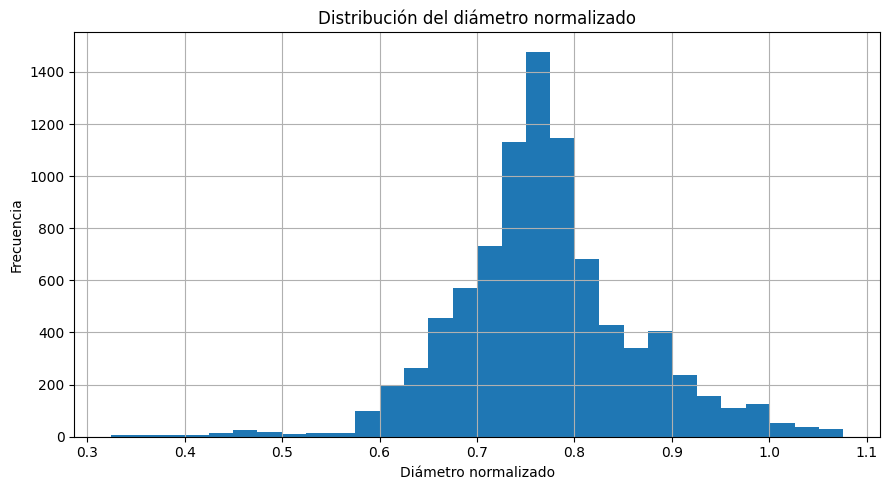

In [8]:
size_feature_records = []

for _, row in df.iterrows():
    size_feature_records.append(estimate_size_features(row["image_path"]))

size_features_df = pd.DataFrame(size_feature_records)
df = pd.concat([df.reset_index(drop=True), size_features_df], axis=1)
size_features_path = TABLES_DIR / "08_size_features_summary.csv"
df[["object_area_ratio", "bbox_width_ratio", "bbox_height_ratio", "bbox_area_ratio", "diameter_px_normalized_base", "normalized_diameter"]].describe().T.to_csv(size_features_path, encoding="utf-8")

display(df[["image_id", "quality_label", "product_type", "size_label_manual", "object_area_ratio", "normalized_diameter"]].head())
ax = df["normalized_diameter"].plot(kind="hist", bins=30)
ax.set_title("Distribución del diámetro normalizado")
ax.set_xlabel("Diámetro normalizado")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_normalized_diameter_distribution.png", dpi=160)
plt.show()

## 9. Etiqueta final de tamaño

Primero se respeta el tamaño manual si existe. Para el resto, se calculan umbrales por producto cuando hay suficientes imágenes; si no, se usan umbrales globales.

In [9]:
def quantile_thresholds(values):
    valid_values = pd.Series(values).dropna()
    if len(valid_values) < 3 or valid_values.nunique() < 3:
        return None
    return float(valid_values.quantile(1 / 3)), float(valid_values.quantile(2 / 3))


def label_from_thresholds(value, thresholds):
    if thresholds is None or pd.isna(value):
        return "medium"
    q1, q2 = thresholds
    if value <= q1:
        return "small"
    if value <= q2:
        return "medium"
    return "large"


global_thresholds = quantile_thresholds(df["normalized_diameter"])
product_thresholds = {}

for product_type, group in df.groupby("product_type"):
    thresholds = quantile_thresholds(group["normalized_diameter"])
    if thresholds is not None and len(group) >= MIN_GROUP_SIZE_FOR_SIZE_THRESHOLDS:
        product_thresholds[product_type] = thresholds

size_labels = []
size_sources = []

for _, row in df.iterrows():
    manual_label = row["size_label_manual"]
    if manual_label in VALID_SIZE_LABELS:
        size_labels.append(manual_label)
        size_sources.append("manual")
        continue

    thresholds = product_thresholds.get(row["product_type"], global_thresholds)
    size_labels.append(label_from_thresholds(row["normalized_diameter"], thresholds))
    size_sources.append("estimated_by_product" if row["product_type"] in product_thresholds else "estimated_global")

df["size_label"] = size_labels
df["size_label_es"] = df["size_label"].map(SIZE_LABELS_ES)
df["size_label_source"] = size_sources

thresholds_payload = {
    "feature": "normalized_diameter",
    "image_size": SIZE_ESTIMATION_IMAGE_SIZE,
    "global": None if global_thresholds is None else {"q1": global_thresholds[0], "q2": global_thresholds[1]},
    "by_product": {key: {"q1": value[0], "q2": value[1]} for key, value in product_thresholds.items()}
}

SIZE_THRESHOLDS_PATH.write_text(json.dumps(thresholds_payload, indent=2, ensure_ascii=False), encoding="utf-8")
size_distribution = pd.crosstab(df["size_label_source"], df["size_label"]).reindex(columns=VALID_SIZE_LABELS, fill_value=0)
size_distribution_path = TABLES_DIR / "09_size_distribution.csv"
size_distribution.to_csv(size_distribution_path, encoding="utf-8")

print("Umbrales de tamaño:", SIZE_THRESHOLDS_PATH)
display(size_distribution)
display(df[["image_id", "product_type", "normalized_diameter", "size_label", "size_label_source"]].head())

Umbrales de tamaño: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\size_thresholds.json


size_label,small,medium,large
size_label_source,,,
estimated_by_product,2939,2933,2931


,image_id,product_type,normalized_diameter,size_label,size_label_source
0,img_bea47128a130,apple,0.712778,small,estimated_by_product
1,img_f5608315e131,apple,0.751698,small,estimated_by_product
2,img_086a3da0b9de,apple,0.773771,medium,estimated_by_product
3,img_254e792d4b01,apple,0.762993,medium,estimated_by_product
4,img_6076a7832114,apple,0.791627,medium,estimated_by_product


## 10. Revisión mínima antes de particionar

Se comprueba que haya suficientes imágenes y al menos dos clases de calidad para crear una partición útil.

In [10]:
df = df[df["quality_label"].isin(VALID_QUALITY_LABELS)].copy()
df = df[df["size_label"].isin(VALID_SIZE_LABELS)].copy()
df = df.reset_index(drop=True)

if len(df) < 5:
    raise ValueError("No hay suficientes imágenes válidas para crear train, validation y test.")

if df["quality_label"].nunique() < 2:
    raise ValueError("Se necesitan al menos dos clases de calidad para entrenar y evaluar modelos.")

quality_counts = df["quality_label"].value_counts().reindex(VALID_QUALITY_LABELS, fill_value=0)
size_counts = df["size_label"].value_counts().reindex(VALID_SIZE_LABELS, fill_value=0)

display(pd.DataFrame({"quality_count": quality_counts}))
display(pd.DataFrame({"size_count": size_counts}))

,quality_count
quality_label,
bad,1564
regular,4610
good,2629


,size_count
size_label,
small,2939
medium,2933
large,2931


## 11. Partición `train`, `val` y `test`

La partición intenta estratificar por calidad y tamaño. Si alguna combinación queda con pocos ejemplos, baja a calidad; si tampoco es viable, divide sin estratificación.

In [11]:
def stratify_series(data):
    combined = data["quality_label"].astype(str) + "_" + data["size_label"].astype(str)
    combined_counts = combined.value_counts()
    if len(combined_counts) > 1 and combined_counts.min() >= 2:
        return combined, "quality_size"

    quality = data["quality_label"].astype(str)
    quality_counts_local = quality.value_counts()
    if len(quality_counts_local) > 1 and quality_counts_local.min() >= 2:
        return quality, "quality"

    return None, "none"


def safe_train_test_split(data, test_size):
    stratify_values, stratify_name = stratify_series(data)
    try:
        left, right = train_test_split(data, test_size=test_size, random_state=RANDOM_STATE, stratify=stratify_values)
    except ValueError:
        left, right = train_test_split(data, test_size=test_size, random_state=RANDOM_STATE, stratify=None)
        stratify_name = "none"
    return left, right, stratify_name


temp_ratio = VAL_RATIO + TEST_RATIO
train_df, temp_df, first_stratify = safe_train_test_split(df, temp_ratio)
second_test_size = TEST_RATIO / temp_ratio
val_df, test_df, second_stratify = safe_train_test_split(temp_df, second_test_size)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df = pd.concat([train_df, val_df, test_df], ignore_index=True)
df = df.sort_values(["split", "quality_label", "size_label", "product_type", "file_name"]).reset_index(drop=True)

split_table = pd.DataFrame({
    "split": ["train", "val", "test"],
    "count": [len(train_df), len(val_df), len(test_df)],
    "percentage": [round(len(train_df) / len(df) * 100, 2), round(len(val_df) / len(df) * 100, 2), round(len(test_df) / len(df) * 100, 2)]
})

print("Estratificación primer corte:", first_stratify)
print("Estratificación segundo corte:", second_stratify)
display(split_table)

Estratificación primer corte: quality_size
Estratificación segundo corte: quality_size


,split,count,percentage
0,train,5281,59.99
1,val,1761,20.00
2,test,1761,20.00


## 12. Guardado de imágenes procesadas

Las imágenes se guardan cuadradas, en RGB y redimensionadas a 128 x 128. La carpeta queda organizada por partición y calidad.

In [12]:
def prepare_processed_directories():
    if RESET_PROCESSED_DIR and PROCESSED_DIR.exists():
        shutil.rmtree(PROCESSED_DIR)

    for split_name in ["train", "val", "test"]:
        for quality_label in VALID_QUALITY_LABELS:
            (PROCESSED_DIR / split_name / QUALITY_FOLDER_NAMES[quality_label]).mkdir(parents=True, exist_ok=True)


def to_project_relative_path(path):
    return path.relative_to(PROJECT_ROOT).as_posix()


def save_processed_image(row):
    image = read_rgb_image(row["image_path"])
    processed_image = pad_image(image, IMAGE_SIZE)
    output_name = f"{row['image_id']}_{row['quality_label']}_{row['size_label']}.jpg"
    output_path = PROCESSED_DIR / row["split"] / QUALITY_FOLDER_NAMES[row["quality_label"]] / output_name
    processed_image.save(output_path, format="JPEG", quality=95)
    return to_project_relative_path(output_path)


prepare_processed_directories()
df["processed_relative_path"] = [save_processed_image(row) for _, row in df.iterrows()]

print("Imágenes procesadas guardadas:", len(df))
display(df[["image_id", "split", "quality_label", "size_label", "processed_relative_path"]].head())

Imágenes procesadas guardadas: 8803


,image_id,split,quality_label,size_label,processed_relative_path
0,img_a27df13fbb51,test,bad,large,data/processed/test/bad/img_a27df13fbb51_bad_large.jpg
1,img_dc19c13d9fbc,test,bad,large,data/processed/test/bad/img_dc19c13d9fbc_bad_large.jpg
2,img_045241671188,test,bad,large,data/processed/test/bad/img_045241671188_bad_large.jpg
3,img_a80e5be2b61d,test,bad,large,data/processed/test/bad/img_a80e5be2b61d_bad_large.jpg
4,img_0b44f5613ee8,test,bad,large,data/processed/test/bad/img_0b44f5613ee8_bad_large.jpg


## 13. Guardado de metadatos procesados

Se guardan los CSV finales que usarán los notebooks de modelos clásicos y de redes neuronales.

In [13]:
df_export = df.drop(columns=["image_path"], errors="ignore").copy()
train_export = df_export[df_export["split"] == "train"].copy().reset_index(drop=True)
val_export = df_export[df_export["split"] == "val"].copy().reset_index(drop=True)
test_export = df_export[df_export["split"] == "test"].copy().reset_index(drop=True)

df_export.to_csv(LABELS_PROCESSED_PATH, index=False, encoding="utf-8")
train_export.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
val_export.to_csv(VAL_PATH, index=False, encoding="utf-8")
test_export.to_csv(TEST_PATH, index=False, encoding="utf-8")

print("labels_processed:", LABELS_PROCESSED_PATH)
print("train:", TRAIN_PATH)
print("val:", VAL_PATH)
print("test:", TEST_PATH)

labels_processed: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\labels_processed.csv
train: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\train_metadata.csv
val: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\val_metadata.csv
test: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\test_metadata.csv


## 14. Distribución final

Estas tablas no repiten el EDA; solo validan que la partición final conserve clases de calidad y tamaño.

quality_label,bad,regular,good
split,,,
train,938,2766,1577
val,313,922,526
test,313,922,526


size_label,small,medium,large
split,,,
train,1763,1759,1759
val,588,587,586
test,588,587,586


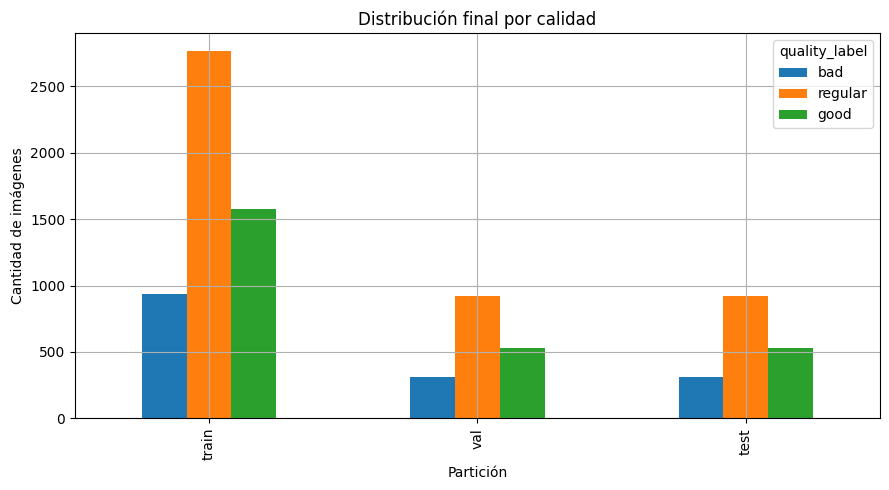

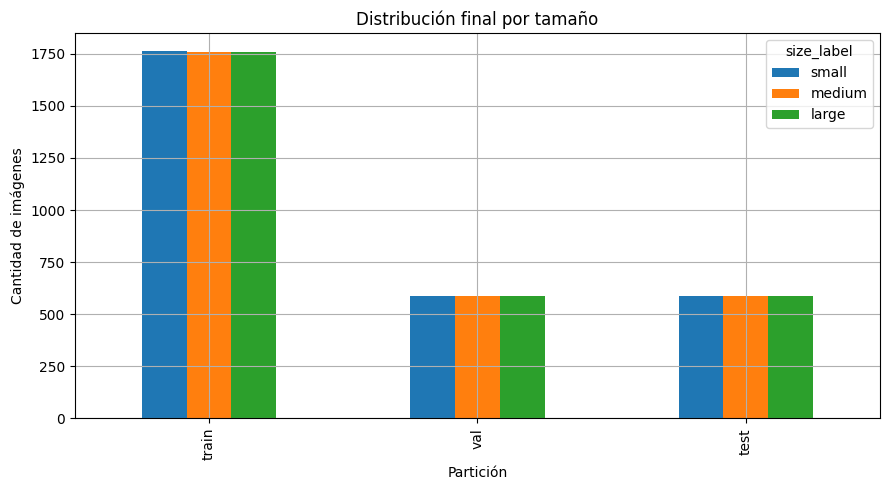

In [14]:
split_quality_table = pd.crosstab(df_export["split"], df_export["quality_label"]).reindex(index=["train", "val", "test"], columns=VALID_QUALITY_LABELS, fill_value=0)
split_size_table = pd.crosstab(df_export["split"], df_export["size_label"]).reindex(index=["train", "val", "test"], columns=VALID_SIZE_LABELS, fill_value=0)
split_product_table = pd.crosstab(df_export["split"], df_export["product_type"])

split_quality_table.to_csv(ANNOTATIONS_DIR / "split_quality_distribution.csv", encoding="utf-8")
split_size_table.to_csv(ANNOTATIONS_DIR / "split_size_distribution.csv", encoding="utf-8")
split_product_table.to_csv(ANNOTATIONS_DIR / "split_product_distribution.csv", encoding="utf-8")

display(split_quality_table)
display(split_size_table)

ax = split_quality_table.plot(kind="bar")
ax.set_title("Distribución final por calidad")
ax.set_xlabel("Partición")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_split_quality_distribution.png", dpi=160)
plt.show()

ax = split_size_table.plot(kind="bar")
ax.set_title("Distribución final por tamaño")
ax.set_xlabel("Partición")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_split_size_distribution.png", dpi=160)
plt.show()

## 15. Función reutilizable de predicción de tamaño

Esta función permite probar una imagen individual y obtener su tamaño relativo con los mismos umbrales calculados por el cuaderno.

In [15]:
def predict_size_from_image_path(image_path, product_type="unknown"):
    path = build_image_path(image_path)
    features = estimate_size_features(path)
    payload = json.loads(SIZE_THRESHOLDS_PATH.read_text(encoding="utf-8"))
    by_product = payload.get("by_product", {})
    selected = by_product.get(str(product_type).lower().strip(), payload.get("global"))

    if selected is None:
        size_label = "medium"
    else:
        size_label = label_from_thresholds(features["normalized_diameter"], (selected["q1"], selected["q2"]))

    return {
        "size_label": size_label,
        "size_label_es": SIZE_LABELS_ES[size_label],
        "normalized_diameter": features["normalized_diameter"],
        "object_area_ratio": features["object_area_ratio"]
    }


example_row = df_export.iloc[0]
predict_size_from_image_path(example_row["relative_path"], example_row["product_type"])

{'size_label': 'large',
 'size_label_es': 'grande',
 'normalized_diameter': 0.929389,
 'object_area_ratio': 0.678398}

## 16. Muestra de imágenes procesadas

Se revisa visualmente que el guardado final esté correcto.

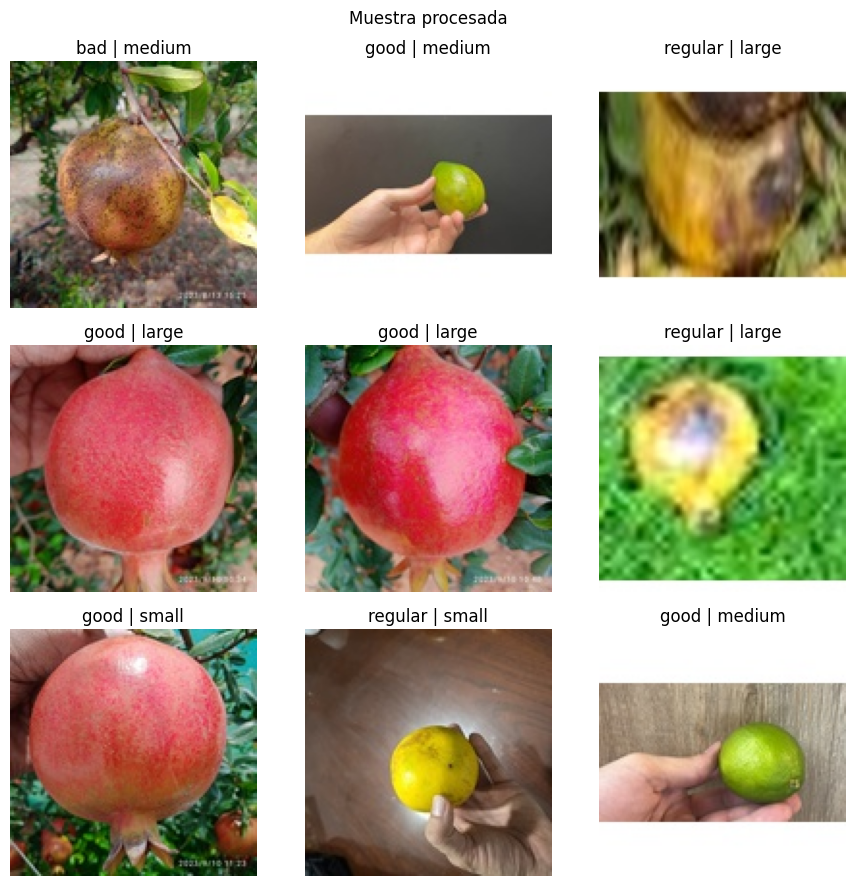

In [16]:
def show_processed_grid(data, title, n=9):
    if data.empty:
        print("No hay imágenes para visualizar.")
        return

    sample = data.sample(min(n, len(data)), random_state=RANDOM_STATE)
    cols = 3
    rows = math.ceil(len(sample) / cols)
    plt.figure(figsize=(cols * 3, rows * 3))

    for index, (_, row) in enumerate(sample.iterrows(), start=1):
        image_path = PROJECT_ROOT / row["processed_relative_path"]
        image = Image.open(image_path)
        plt.subplot(rows, cols, index)
        plt.imshow(image)
        plt.title(f"{row['quality_label']} | {row['size_label']}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "10_processed_sample.png", dpi=160)
    plt.show()


show_processed_grid(df_export, "Muestra procesada")

## 17. Resumen final

El cuaderno deja los datos listos para entrenar dos tareas: clasificación de calidad y clasificación/estimación de tamaño.

In [17]:
preprocessing_summary = pd.DataFrame({
    "metric": [
        "total_images_after_validation",
        "removed_invalid_images",
        "removed_duplicate_images",
        "train_images",
        "val_images",
        "test_images",
        "image_size",
        "quality_classes",
        "size_classes",
        "size_thresholds_path",
        "labels_processed_path",
        "train_path",
        "val_path",
        "test_path",
        "processed_dir"
    ],
    "value": [
        len(df_export),
        len(invalid_df),
        len(duplicated_df),
        len(train_export),
        len(val_export),
        len(test_export),
        f"{IMAGE_SIZE}x{IMAGE_SIZE}",
        ", ".join(VALID_QUALITY_LABELS),
        ", ".join(VALID_SIZE_LABELS),
        SIZE_THRESHOLDS_PATH.relative_to(PROJECT_ROOT).as_posix(),
        LABELS_PROCESSED_PATH.relative_to(PROJECT_ROOT).as_posix(),
        TRAIN_PATH.relative_to(PROJECT_ROOT).as_posix(),
        VAL_PATH.relative_to(PROJECT_ROOT).as_posix(),
        TEST_PATH.relative_to(PROJECT_ROOT).as_posix(),
        PROCESSED_DIR.relative_to(PROJECT_ROOT).as_posix()
    ]
})

preprocessing_summary.to_csv(PREPROCESSING_SUMMARY_PATH, index=False, encoding="utf-8")
display(preprocessing_summary)
print("Resumen guardado en:", PREPROCESSING_SUMMARY_PATH)

,metric,value
0,total_images_after_validation,8803
1,removed_invalid_images,0
2,removed_duplicate_images,33
3,train_images,5281
4,val_images,1761
5,test_images,1761
6,image_size,128x128
7,quality_classes,"bad, regular, good"
8,size_classes,"small, medium, large"
9,size_thresholds_path,data/annotations/size_thresholds.json


Resumen guardado en: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\preprocessing_summary.csv
